In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_median_mae(df):

    def q25(x):
        return x.quantile(0.25)
    def q75(x):
        return x.quantile(0.75)

    temp = df.groupby('train_size').agg({'mae': ['mean', 'median', q25, q75]})
    temp.columns = ['xgboost_mean', 'xgboost_median', 'xgboost_q25', 'xgboost_q75']
    return temp

def plot_median_mae(temp, title='', label=''):
    plt.plot(temp.index, temp['xgboost_median'], label=label, marker='o')

    # fill_between IQR
    plt.fill_between(temp.index, temp['xgboost_q25'], temp['xgboost_q75'], alpha=0.4)
    plt.legend()
    plt.grid()

    plt.xlabel('Train size')
    plt.ylabel('MAE')
    plt.title(title)

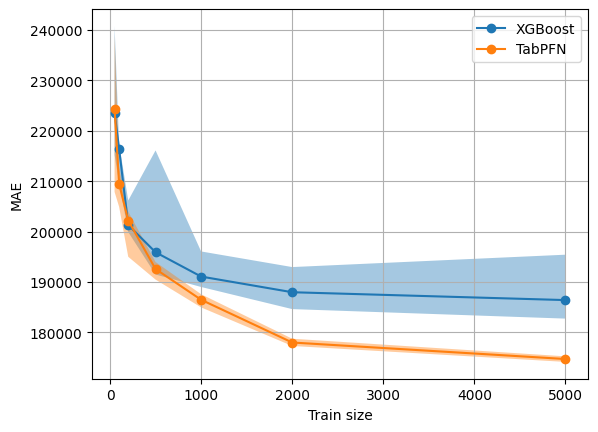

In [4]:
df = pd.read_csv('../../results_temp/data_scaling/cook_county_no_preprocessing/results.csv')

df1 = df[df['model'] == 'xgboost']
df2 = df[df['model'] == 'tabpfn']

temp1 = get_median_mae(df1)
temp2 = get_median_mae(df2)

plot_median_mae(temp1, label='XGBoost')
plot_median_mae(temp2, label='TabPFN')
plt.legend()
plt.grid()

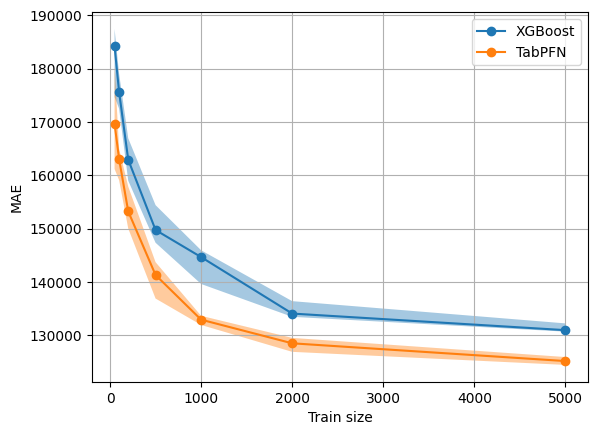

In [6]:
# with preprocessing
df = pd.read_csv('../../results_temp/data_scaling/cook_county_data_scaling//results.csv')

df1 = df[df['model'] == 'xgboost']
df2 = df[df['model'] == 'tabpfn']

temp1 = get_median_mae(df1)
temp2 = get_median_mae(df2)

plot_median_mae(temp1, label='XGBoost')
plot_median_mae(temp2, label='TabPFN')
plt.legend()
plt.grid()

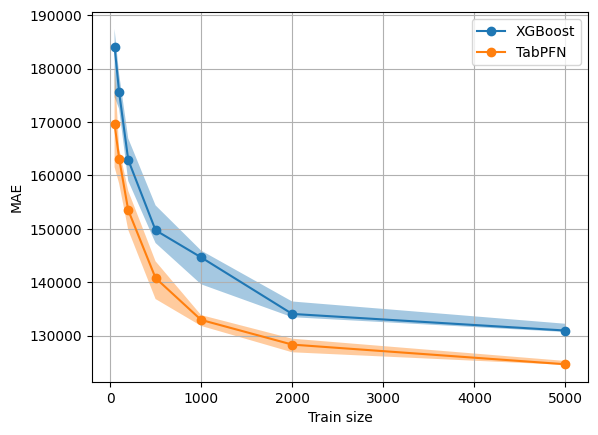

In [9]:
temp1 = get_median_mae(df1)
temp2 = get_median_mae(df2)

plot_median_mae(temp1, label='XGBoost')
plot_median_mae(temp2, label='TabPFN')
plt.legend()
plt.grid()

In [9]:
import tabpfn

In [10]:
from tabpfn.finetuning.finetuned_regressor import FinetunedTabPFNRegressor

ModuleNotFoundError: No module named 'tabpfn.finetuning'

In [11]:
from tabpfn.preprocessing import DatasetCollectionWithPreprocessing